In [34]:
rawdata = r""" Source         & $v$ line                               & RMS    & Beam Size        & Beam Size      & Disk Radius & Distance & Luminosity\\
                &                                        & K      & Arcsec           & AU             & au          & kpc      & \lsun     \\
 \hline      
 SrcI           & NaCl J=18-17 v=0                       &        & $0.04\times0.02$ & $16\times8$    & 50$^n$      & 0.4      & $10^4$    \\
 G17            & \water                                 &        & $0.04\times0.02$ & $80\times50$   &             & 2.2$^c$  & 1.7\ee{4} \\
 GGD27          & SO $6_5-5_4$                           & 0.3    & $0.10\times0.07$ & $130\times90$  &             & 1.3$^a$  & 1.2\ee{4} \\
 G5.89 mm15     & \water                                 & 1.5    & $0.06\times0.04$ & $170\times120$ &             & 3.0$^b$  & -         \\
 G351.77mm1     & \water                                 &        & $0.05\times0.04$ & $115\times83$  &             & 2.2$^c$  & 1.7\ee{4} \\
 G351.77mm2     & \water                                 &        & $0.05\times0.04$ & $115\times83$  &             & 2.2$^c$  & 1.7\ee{4} \\
 I16547a        & \water                                 &        & $0.06\times0.06$ & $180\times180$ &             & 2.9$^c$  & $<1\ee{5}$\\
 I16547b        & \water                                 &        & $0.06\times0.06$ & $180\times180$ &             & 2.9$^c$  & $<1\ee{5}$\\
 NGC6334IN SMA6 & \water                                 & 5-10   & $0.08\times0.05$ & $110\times67$  &             & 1.3$^d$  &           \\
 NGC6334IN SMA1bd & \water                               & 5-10   & $0.08\times0.05$ & $110\times67$  &             & 1.3$^d$  &           \\
 NGC6334Imm2b   & \water                                 &        & $0.09\times0.05$ & $110\times67$  &             & 1.3$^d$  &           \\
 NGC6334Imm1b   & \water                                 &        & $0.09\times0.05$ & $110\times67$  &             & 1.3$^d$  &           \\
 NGC6334Imm1d   & \water                                 &        & $0.09\times0.05$ & $110\times67$  &             & 1.3$^d$  &           \\
 G11.92mm1      & CH$_3$OH 10(2,8)-9(3,7)A,vt=0	         & 10     & $0.10\times0.07$ & $347\times234$ & 850$^m$     & 3.3$^e$  & $10^4$    \\
 IRAS18089      & CH$_3$OH 10(2,8)-9(3,7)A,vt=0          &        & $0.06\times0.05$ & $150\times100$ &             & 2.3$^f$  & 1.3\ee{4} \\
 IRAS16562      & H30$\alpha$                            &        & $0.11\times0.05$ & $240\times120$ &             & 2.3$^g$  &           \\
 G333.60mm1     & SO 6(5)-5(4)                           &        & $0.07\times0.06$ & $400\times300$ &             & 5.3$^h$  &           \\
 G333.60mm2     & SO 6(5)-5(4)                           &        & $0.07\times0.06$ & $400\times300$ &             & 5.3$^h$  &           \\
 G335           &                                        &        & $0.07\times0.06$ & $240\times210$ &             & 3.3$^i$  &           \\
 G29.96         & -                                      &        & $0.10\times0.07$ & $610\times430$ &             & 7.4$^j$  &           \\
 W33A MM1-Main  & \water                                 &        & $0.10\times0.07$ & $240\times160$ &             & 2.6$^k$  &           \\
 S255IR         &                                        &        & $0.03\times0.02$ & $70\times50$   &             & 1.6$^k$  &           \\
 G34.43         & no clear disk                          &        & $0.11\times0.08$ & $420\times300$ &             & 1.6$^l$  &           \\
"""

In [35]:
from astropy.table import Table
from astropy.io import ascii

In [36]:
# first row is junk
tbl = Table.read('/orange/adamginsburg/salt/2022_dihca_disks/observations.tex', format='latex', )[1:]
tbl

Source,$v$ line,Beam Size,Beam Size_1,Distance
str27,str16,str16,str14,str7
Orion SrcI,NaCl J=18-17 v=0,$0.04\times0.02$,$16\times8$,0.4
G17,\water,$0.04\times0.02$,$80\times50$,2.2$^c$
IRAS18162 GGD27,SO $6_5-5_4$,$0.10\times0.07$,$130\times90$,1.3$^a$
G5.89 mm15,\water,$0.06\times0.04$,$170\times120$,3.0$^b$
G351.77mm1,\water,$0.05\times0.04$,$115\times83$,2.2$^c$
G351.77mm2,\water,$0.05\times0.04$,$115\times83$,2.2$^c$
G351.77mm12,\water,$0.05\times0.04$,$115\times83$,2.2$^c$
I16547A,\water,$0.06\times0.06$,$180\times180$,2.9$^c$
I16547B,\water,$0.06\times0.06$,$180\times180$,2.9$^c$


In [37]:
nuline = tbl.colnames[1]

In [38]:
pwd

'/orange/adamginsburg/salt/notebooks'

In [39]:
import json
distance_dict = {k:v for k, v in zip(tbl['Source'],tbl['Distance'])}
nuline_dict = {k:v for k, v in zip(tbl['Source'],tbl[nuline])}
with open('distance_map.json', 'w') as fh:
    json.dump(distance_dict, fh)
with open('nuline_map.json', 'w') as fh:
    json.dump(nuline_dict, fh)

In [40]:
from astropy.table import Table
import re

def load_detections(path):
    """Parse a tabular LaTeX detections file robustly.

    Handles:
      - \\hline separators
      - \\multicolumn group-header rows (e.g. HOTDISK subtable)
      - empty rows
    Returns an astropy Table with one row per data line plus a 'group' column.
    """
    with open(path) as fh:
        lines = fh.readlines()
    # find tabular env
    body = []
    in_tab = False
    for line in lines:
        s = line.strip()
        if r"\begin{tabular}" in s:
            in_tab = True
            continue
        if r"\end{tabular}" in s:
            in_tab = False
            continue
        if in_tab:
            body.append(s)

    cols = None
    group = "main"
    rows = []
    for raw in body:
        if not raw or raw.startswith("%"):
            continue
        if raw.startswith(r"\hline"):
            continue
        # group-header row via \multicolumn
        m = re.search(r"\\multicolumn\{\d+\}\{[^}]*\}\{(.*?)\}\s*\\\\", raw)
        if m:
            txt = m.group(1)
            # strip \textit{} and \citep{...}
            txt = re.sub(r"\\textit\{(.*?)\}", r"\1", txt)
            txt = re.sub(r"\\citep[^{]*\{[^}]*\}", "", txt)
            group = txt.strip().split()[0] if txt.strip() else "group"
            continue
        # strip trailing \\
        cells = raw.rstrip("\\").strip()
        if not cells:
            continue
        # split on & not inside braces - simple split works here
        parts = [p.strip() for p in cells.split("&")]
        if cols is None:
            cols = parts
            continue
        if len(parts) != len(cols):
            # malformed line, skip
            continue
        rows.append(parts + [group])

    tbl = Table(rows=rows, names=list(cols) + ["group"])
    return tbl


dtbl = load_detections("/orange/adamginsburg/salt/2022_dihca_disks/detections.tex")
dtbl

Source,disk,H$_2$O,NaCl,KCl,SiO,RRL,COMs,SiS,SO,PN,group
str27,str5,str4,str4,str3,str3,str4,str4,str4,str4,str4,str7
Orion SrcI,yes,yes,yes,yes,yes,no,no,yes,yes,?,main
G17,yes,yes,yes,yes,yes,yes,no,yes,yes*,no,main
I16547A,yes-c,yes,yes*,no,yes,no,yes,yes,yes,yes,main
I16547B,yes-c,yes,yes*,no,yes,no,yes,yes,yes,yes,main
G351.77mm1,yes-c,yes,yes,no,yes,no*,no,yes,no,yes,main
G351.77mm2,unres,yes,yes*,no,no,yes,no,no,no,no*,main
G351.77mm12,unres,yes,yes*,no,yes,no,no,yes,no,yes,main
W33A mm1-main,unres,yes*,yes*,no,yes,yes*,yes,yes*,yes,yes,main
NGC6334Imm1b,yes-c,yes,yes,yes,yes,no,yes*,yes,no*,yes*,main


In [41]:
assert 'W33A mm1-main' in dtbl['Source']
assert 'W33A mm1-main' in tbl['Source']

# old, non-automatic version

dtbl = Table.read(r"""    Source         & disk  & H$_2$O &  NaCl & KCl & SiO & RRL & COMs & SiS & SO \\
    \hline  &
    SrcI           & yes   & yes    &  yes  & yes & yes & No  & No   & Yes & yes     \\
    G17            & yes   & yes    &  yes  & yes & yes & Yes & No   & Yes & yes*    \\
    I16547-Ea      & yes   & yes    &  yes* & no  & yes & No  & Yes  & Yes & yes     \\
    I16547-Eb      & yes   & yes    &  yes* & no  & yes & No  & Yes  & Yes & yes     \\
    G351.77mm1     & yes   & yes    &  yes  & no  & yes & no* & no   & yes & no      \\
    G351.77mm2     & unres & yes    &  yes* & no  & no  & yes & no   & no  & no      \\
    W33A MM1-Main  & unres & yes*   &  yes* & no  & yes & yes*& yes  & yes*& yes     \\
    NGC6334Imm2b   & unres & yes    &  yes* & no  & yes & no  & yes  & yes & yes     \\
    NGC6334Imm1b   & yes   & yes    &  yes  & yes & yes & no  & yes* & yes & no*     \\
    \hline KCl &
    G5.89 mm15     & cont  & no     &  no   & no  & ?   & no  & no   & no  & no      \\
    GGD27          & yes   & no     &  no   & no  & ?   & no  & yes  & no  & YES     \\
    NGC6334IN SMA6 & no    & yes*   &  no   & no  & no  & no  & yes  & no  & no      \\
  NGC6334IN SMA1bd & no    & no*    &  no   & no  & no  & no  & yes  & no  & no      \\
    G11.92mm1      & yes   & no     &  no   & no  & yes & no  & yes  & yes*& yes     \\
    IRAS18089      & yes   & no     &  no   & no  & yes & no  & yes  & yes*& yes     \\
    IRAS16562      & no    & no     &  no   & no  & yes & yes & ext  & no  & ext     \\
    G333.60mm1     & no    & no     &  no   & no  & no* & no  & yes  & no  & yes     \\
    G333.60mm2     & yes*  & no     &  no   & no  & no* & no  & yes  & no  & yes     \\
    G335           & no    & no     &  no   & no  & yes & no  & yes  & no  & no*     \\
    G29.96         & no    & no     &  no   & no  & yes & no  & yes  & no* & no*     \\
    G34.43         & no    & no     &  no   & no  & no* & no* & yes  & no  & yes     \\
    S255IR         & no*   & no*    &  no   & no  & yes & yes & yes  & no  & yes     \\   """,
                  format='latex',
                  data_start=1,
                  header_start=0)
dtbl

In [42]:
from astropy import table

In [43]:
mtbl = table.join(tbl, dtbl, keys=['Source'])

In [44]:
import warnings
missing = [row['Source'] for row in tbl if row['Source'] not in dtbl['Source']]
if missing:
    warnings.warn(f"Sources in observations.tex absent from detections.tex (likely "
                  f"superseded by HOTDISK subtable entries): {missing}")
extra = [s for s in dtbl['Source'] if s not in tbl['Source']]
if extra:
    print(f"Detection-only sources (not in observations.tex, no beam metadata): {extra}")

Detection-only sources (not in observations.tex, no beam metadata): [np.str_('IRAS18089  I18089-1732'), np.str_('I07299-1651'), np.str_('I08303-4303'), np.str_('I16484-4603'), np.str_('I17008-4040'), np.str_('I17016-4124'), np.str_('I18117-1753'), np.str_('I18434-0242'), np.str_('I18469-0132'), np.str_('I18507+0121'), np.str_('I18517+0437')]


/tmp/ipykernel_498606/776578992.py:4: UserWarning: Sources in observations.tex absent from detections.tex (likely superseded by HOTDISK subtable entries): [np.str_('IRAS18089 I18089-1732'), np.str_('G29.96 submm1'), np.str_('G34.43mm1')]
  warnings.warn(f"Sources in observations.tex absent from detections.tex (likely "


In [45]:
mtbl

Source,$v$ line,Beam Size,Beam Size_1,Distance,disk,H$_2$O,NaCl,KCl,SiO,RRL,COMs,SiS,SO,PN,group
str27,str16,str16,str14,str7,str5,str4,str4,str3,str3,str4,str4,str4,str4,str4,str7
G11.92mm1,SO $6_5-5_4$,$0.10\times0.07$,$347\times234$,3.3$^e$,yes,no,no,no,yes,no,yes,yes*,yes,yes*,main
G17,\water,$0.04\times0.02$,$80\times50$,2.2$^c$,yes,yes,yes,yes,yes,yes,no,yes,yes*,no,main
G333.23mm1,SO $6_5-5_4$,$0.07\times0.06$,$400\times300$,5.3$^h$,no,no,no,no,no*,no,yes,no,yes,yes*,main
G333.23mm2,SO $6_5-5_4$,$0.07\times0.06$,$400\times300$,5.3$^h$,yes*,no,no,no,no*,no,yes,no,yes,yes*,main
G335 ALMA1,no clear disk,$0.07\times0.06$,$240\times210$,3.3$^i$,no,no,no,no,yes,no,yes,no,no*,no,main
G351.77mm1,\water,$0.05\times0.04$,$115\times83$,2.2$^c$,yes-c,yes,yes,no,yes,no*,no,yes,no,yes,main
G351.77mm12,\water,$0.05\times0.04$,$115\times83$,2.2$^c$,unres,yes,yes*,no,yes,no,no,yes,no,yes,main
G351.77mm2,\water,$0.05\times0.04$,$115\times83$,2.2$^c$,unres,yes,yes*,no,no,yes,no,no,no,no*,main
G5.89 mm15,\water,$0.06\times0.04$,$170\times120$,3.0$^b$,cont,no,no,no,?,no,no,no,no,no,main


In [74]:
dtbl.show_in_notebook()

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

In [47]:
def get_bmaj(x):
    return int(x.split('\\')[0].strip("$"))
bmaj = list(map(get_bmaj, mtbl['Beam Size_1']))

In [48]:
%matplotlib inline
import pylab as pl

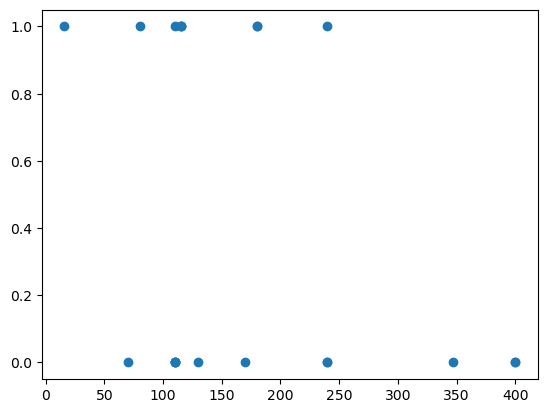

In [49]:
pl.plot(bmaj, ['yes' in key for key in mtbl['NaCl']], 'o')

In [50]:
import sklearn.linear_model

In [51]:
import numpy as np

In [52]:
from sklearn.linear_model import LogisticRegression
logisticfit = LogisticRegression(random_state=0).fit(np.array(bmaj).reshape(-1,1), 
                                                     np.array(['yes' in key for key in mtbl['NaCl']]).reshape(-1,1))

/blue/adamginsburg/adamginsburg/miniconda3/envs/python313/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


We need to treat each _observation_ independently, not each source.

So, we need to filter bmaj & "yes" by region name.  Or distance.

This isn't really automatable.

In [53]:
region_names = ['G11.92', 'W33A', 'S255IR', 'NGC6334Imm', 'NGC6334IN', 'IRAS18089', 'IRAS16562', 'I16547', 'G351.77', 'GGD27', 'G333.23', 'G335', 'G17', 'SrcI', 'G5.89']
missing_regions = [rn for rn in region_names if not any(rn in src for src in mtbl['Source'])]
if missing_regions:
    print(f"Skipping regions absent from joined table: {missing_regions}")
    region_names = [rn for rn in region_names if rn not in missing_regions]
bmaj_reg = {regname:bmaj[ii]
            for ii,srcnm in enumerate(mtbl['Source'])
            for regname in region_names
            if regname in srcnm}
assert len(bmaj_reg) == len(region_names)
nacldet = {regname: False for regname in region_names}
for regname in region_names:
    for row in mtbl:
        if regname in row['Source']:
            if 'yes' in row['NaCl']:
                nacldet[regname] = True

print(bmaj_reg)
print(nacldet)
bmaj_reg_arr = [bmaj_reg[regname] for regname in region_names]
nacldet_arr = [nacldet[regname] for regname in region_names]
print(len(nacldet_arr), len(bmaj_reg), len(region_names))

logisticfit2 = LogisticRegression(random_state=0).fit(np.array(bmaj_reg_arr).reshape(-1,1), 
                                                      np.array(nacldet_arr).reshape(-1,1))

Skipping regions absent from joined table: ['IRAS18089']
{'G11.92': 347, 'G17': 80, 'G333.23': 400, 'G335': 240, 'G351.77': 115, 'G5.89': 170, 'I16547': 180, 'IRAS16562': 240, 'GGD27': 130, 'NGC6334IN': 110, 'NGC6334Imm': 110, 'SrcI': 16, 'S255IR': 70, 'W33A': 240}
{'G11.92': False, 'W33A': True, 'S255IR': False, 'NGC6334Imm': True, 'NGC6334IN': False, 'IRAS16562': False, 'I16547': True, 'G351.77': True, 'GGD27': False, 'G333.23': False, 'G335': False, 'G17': True, 'SrcI': True, 'G5.89': False}
14 14 14


/blue/adamginsburg/adamginsburg/miniconda3/envs/python313/lib/python3.13/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


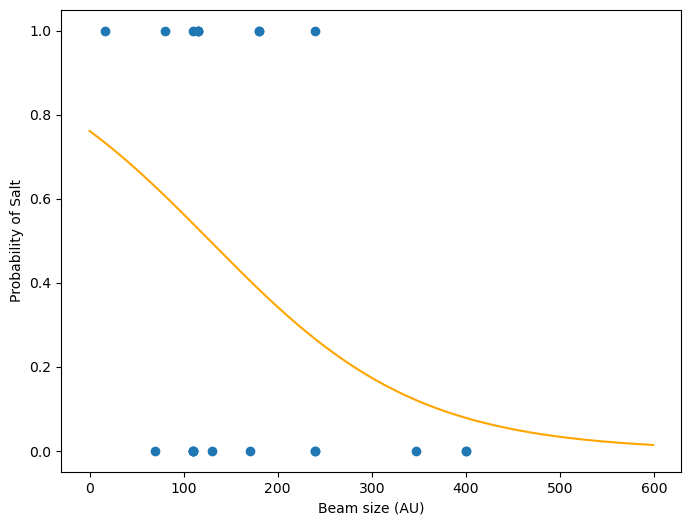

In [54]:
# pl.rcParams['font.size'] = 16
pl.figure(figsize=(8,6))
pl.scatter(bmaj, ['yes' in key for key in mtbl['NaCl']], marker='o', )
pl.plot(np.arange(600), logisticfit.predict_proba(np.arange(600).reshape(-1,1))[:,1], color='orange')
pl.xlabel("Beam size (AU)")
pl.ylabel("Probability of Salt")
pl.savefig('../figures/logistic_P_of_salt.pdf', bbox_inches='tight', dpi=300)

136


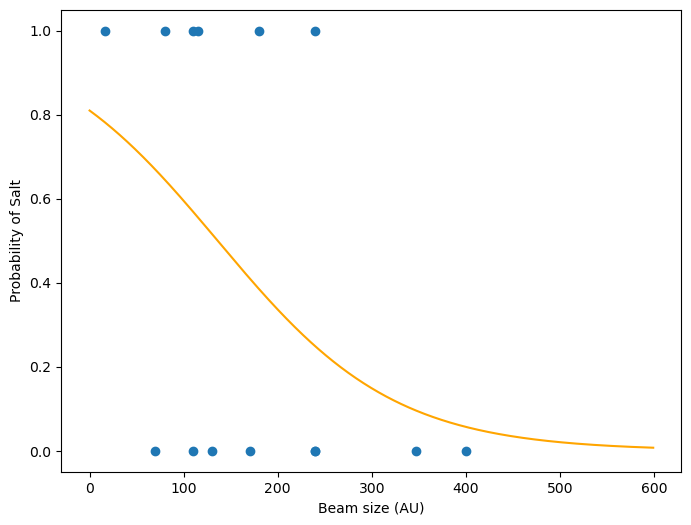

In [55]:
# pl.rcParams['font.size'] = 16
pl.figure(figsize=(8,6))
pl.scatter(bmaj_reg_arr, nacldet_arr, marker='o', )
pl.plot(np.arange(600), logisticfit2.predict_proba(np.arange(600).reshape(-1,1))[:,1], color='orange')
pl.xlabel("Beam size (AU)")
pl.ylabel("Probability of Salt")
pl.savefig('../figures/logistic_P_of_salt.pdf', bbox_inches='tight', dpi=300)
print(np.arange(600)[np.argmin(np.abs(logisticfit2.predict_proba(np.arange(600).reshape(-1,1))[:,1]-0.5))])

In [56]:
logisticfit2.predict_proba([[1]])

array([[0.19165589, 0.80834411]])

In [57]:
import pandas as pd

boolcols = [ 'H$_2$O', 'NaCl', 'SiS', 'PN', 'KCl', 'SiO', 'RRL',  'SO', 'COMs',    ]

def to_trivalued(cell):
    """Map cell text to 1 (detection/tentative), 0 (non-detection/tentative), or NaN (?, ext, not observed)."""
    s = str(cell).strip().lower()
    if s in {"?", "", "ext", "—", "-"}:
        return np.nan
    if "yes" in s:
        return 1.0
    if "no" in s:
        return 0.0
    return np.nan

# Backwards-compat strict-boolean columns on mtbl (treats ? as False)
for boolcol in boolcols:
    try:
        mtbl.add_column(['yes' in str(row).lower() for row in mtbl[boolcol]], name='bool '+boolcol)
    except Exception:
        pass

# NaN-aware tri-state columns on dtbl (preserves ? as missing) for the FULL sample
# including HOTDISK from Kai
for boolcol in boolcols:
    if boolcol in dtbl.colnames and 'tri '+boolcol not in dtbl.colnames:
        dtbl.add_column([to_trivalued(v) for v in dtbl[boolcol]], name='tri '+boolcol)
    # also legacy 'bool ' column for any cells in the notebook that still use it
    if boolcol in dtbl.colnames and 'bool '+boolcol not in dtbl.colnames:
        dtbl.add_column(['yes' in str(row).lower() for row in dtbl[boolcol]], name='bool '+boolcol)

# Build a pandas DataFrame for pairwise-complete correlations on the FULL sample
trifr = pd.DataFrame({bc: list(dtbl['tri '+bc]) for bc in boolcols},
                     index=list(dtbl['Source']))
print(f"Full sample: {len(trifr)} sources (main + HOTDISK)")
print(f"Missing-cell counts:")
print(trifr.isna().sum())

Full sample: 32 sources (main + HOTDISK)
Missing-cell counts:
H$_2$O     0
NaCl       0
SiS        1
PN         7
KCl       10
SiO        5
RRL        5
SO        11
COMs      11
dtype: int64


In [58]:
# Strict (legacy) boolean matrix on full dtbl: ? treated as False
btbl = np.array([dtbl['bool '+bc] for bc in boolcols])
# Pairwise-complete correlation matrix using pandas (handles NaN for ?)
ccs_pw = trifr.corr(method='pearson', min_periods=2).values  # rows/cols ordered as boolcols
print("Pairwise-complete correlation (HOTDISK '?' treated as missing):")
print(np.round(ccs_pw, 2))

Pairwise-complete correlation (HOTDISK '?' treated as missing):
[[ 1.    0.73  0.56  0.36  0.36  0.07 -0.03 -0.17 -0.41]
 [ 0.73  1.    0.75  0.21  0.48  0.23  0.15 -0.03 -0.41]
 [ 0.56  0.75  1.    0.36  0.4   0.53 -0.11  0.33 -0.07]
 [ 0.36  0.21  0.36  1.   -0.05 -0.01 -0.43  0.08  0.13]
 [ 0.36  0.48  0.4  -0.05  1.    0.28  0.1   0.08 -0.29]
 [ 0.07  0.23  0.53 -0.01  0.28  1.    0.11  0.34  0.03]
 [-0.03  0.15 -0.11 -0.43  0.1   0.11  1.    0.18 -0.17]
 [-0.17 -0.03  0.33  0.08  0.08  0.34  0.18  1.    0.41]
 [-0.41 -0.41 -0.07  0.13 -0.29  0.03 -0.17  0.41  1.  ]]


In [59]:
ccs = np.corrcoef(btbl)
ccs[np.triu_indices(ccs.shape[0], 0)] = np.nan

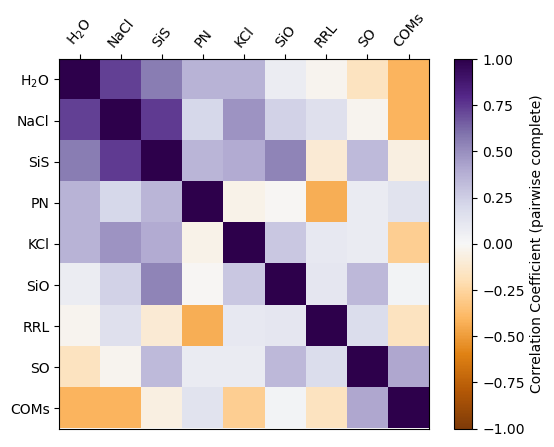

In [60]:
# Pairwise-complete correlation plot (HOTDISK ? treated as missing)
fig = pl.figure()
ax = pl.gca()
ax.xaxis.tick_top()

im = ax.imshow(ccs_pw, cmap='PuOr', vmin=-1, vmax=1)
cb = pl.colorbar(mappable=im)
cb.set_label("Correlation Coefficient (pairwise complete)")
xloc,xlab = pl.xticks()
pl.xticks(ticks=list(range(len(boolcols))), labels=boolcols, rotation=50)
pl.yticks(ticks=list(range(len(boolcols))), labels=boolcols)
pl.axis([-0.5,len(boolcols)-0.5,len(boolcols)-0.5,-0.5])
fig.savefig("../figures/salt_water_so_sis_cross_correlation_redundant.png", bbox_inches='tight', dpi=300)

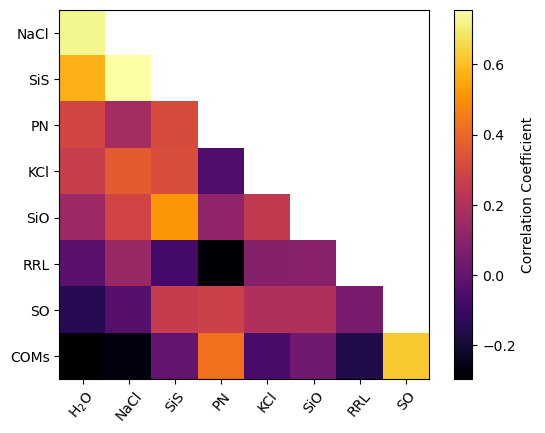

In [61]:
fig = pl.figure()
ax = pl.gca()
im = ax.imshow(ccs[1:,:-1], cmap='inferno')
cb = pl.colorbar(mappable=im)
cb.set_label("Correlation Coefficient")
xloc,xlab = pl.xticks()
pl.xticks(ticks=[0,1,2,3,4,5,6,7], labels=boolcols[:-1], rotation=50)
pl.yticks(ticks=[0,1,2,3,4,5,6,7], labels=boolcols[1:])
pl.axis([-0.5,7.5,7.5,-0.5])
fig.savefig("../figures/salt_water_so_sis_cross_correlation.png", bbox_inches='tight', dpi=300)

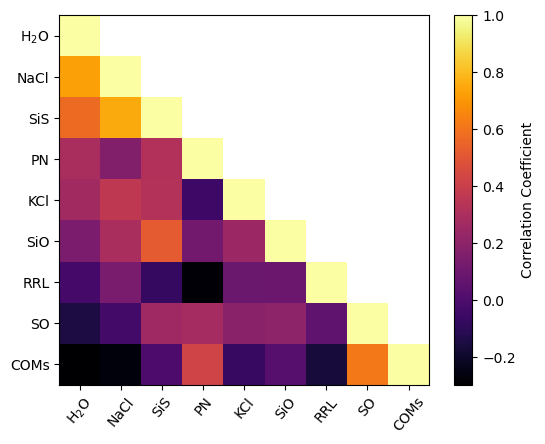

In [62]:
fig = pl.figure()
ax = pl.gca()
ccs2 = np.corrcoef(btbl)
ccs2[np.triu_indices(ccs.shape[0], 1)] = np.nan
im = ax.imshow(ccs2, cmap='inferno')
cb = pl.colorbar(mappable=im)
cb.set_label("Correlation Coefficient")
xloc,xlab = pl.xticks()
pl.xticks(ticks=[0,1,2,3,4,5,6,7,8], labels=boolcols, rotation=50)
pl.yticks(ticks=[0,1,2,3,4,5,6,7,8], labels=boolcols)
pl.axis([-0.5,8.5,8.5,-0.5])
fig.savefig("../figures/salt_water_so_sis_cross_correlation_bigger.png", bbox_inches='tight', dpi=300)

In [63]:
ccs.diagonal()

array([nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [64]:
np.corrcoef(btbl).diagonal()

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

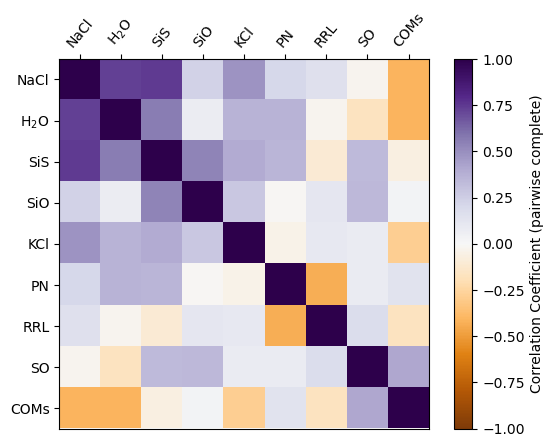

In [65]:
boolcols2 = [ 'NaCl', 'H$_2$O', 'SiS', 'SiO', 'KCl', 'PN',  'RRL',  'SO', 'COMs',    ]

# Pairwise-complete corr in the requested column order
trifr2 = trifr[boolcols2]
ccs2_pw = trifr2.corr(method='pearson', min_periods=2).values

fig = pl.figure()
ax = pl.gca()
ax.xaxis.tick_top()
im = ax.imshow(ccs2_pw, cmap='PuOr', vmin=-1, vmax=1)
cb = pl.colorbar(mappable=im)
cb.set_label("Correlation Coefficient (pairwise complete)")
xloc,xlab = pl.xticks()
pl.xticks(ticks=list(range(len(boolcols2))), labels=boolcols2, rotation=50)
pl.yticks(ticks=list(range(len(boolcols2))), labels=boolcols2)
pl.axis([-0.5,len(boolcols2)-0.5,len(boolcols2)-0.5,-0.5])
fig.savefig("../figures/salt_water_so_sis_cross_correlation_redundant_saltfirst.png", bbox_inches='tight', dpi=300)